In [16]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import os
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load interpolated dataset
file_path = r"E:\file_main\Major_1\fauna-forecast\data\raw\bison_population_interpolated.csv"
df = pd.read_csv(file_path)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

# Detect outliers using z-score
df['zscore'] = zscore(df['Population'].fillna(0))
outliers = df[np.abs(df['zscore']) > 3]
print("Outliers:\n", outliers[['Population']])


Outliers:
 Empty DataFrame
Columns: [Population]
Index: []


In [2]:
# Make cleaned copy
df_clean = df.copy()
df_clean.loc[outliers.index, 'Population'] = np.nan
df_clean['Population'] = df_clean['Population'].interpolate(method='linear')

# Optional smoothing (5-year rolling mean)
df_clean['Smoothed'] = df_clean['Population'].rolling(window=5, center=True).mean()

# Save cleaned dataset
save_path = r"E:\file_main\Major_1\fauna-forecast\data\cleaned\bison_population_cleaned.csv"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
df_clean.to_csv(save_path)
print(f"Cleaned dataset saved to: {save_path}")


Cleaned dataset saved to: E:\file_main\Major_1\fauna-forecast\data\cleaned\bison_population_cleaned.csv


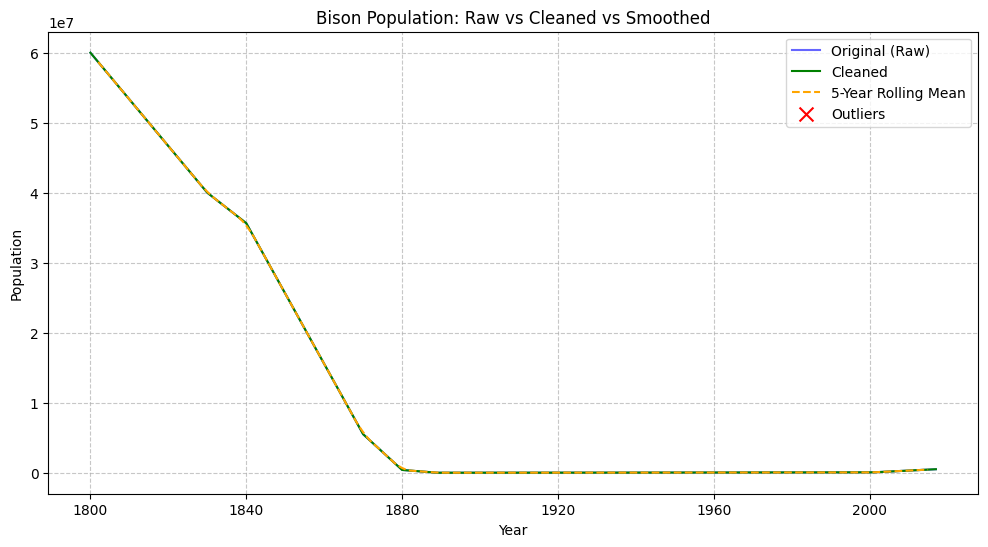

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Population'], label="Original (Raw)", alpha=0.6, color="blue")
plt.plot(df_clean.index, df_clean['Population'], label="Cleaned", color="green")
plt.plot(df_clean.index, df_clean['Smoothed'], label="5-Year Rolling Mean", color="orange", linestyle="--")
plt.scatter(outliers.index, outliers['Population'], color="red", marker="x", s=100, label="Outliers")
plt.title("Bison Population: Raw vs Cleaned vs Smoothed")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()
